# Chord Diagram — REF_* Co-occurrence
Shows which energy refurbishment measures are typically done together.
Base: all 1,184 agents with at least one REF measure. REF_11 (Other) is excluded.

Agents with at least one REF measure: 1184


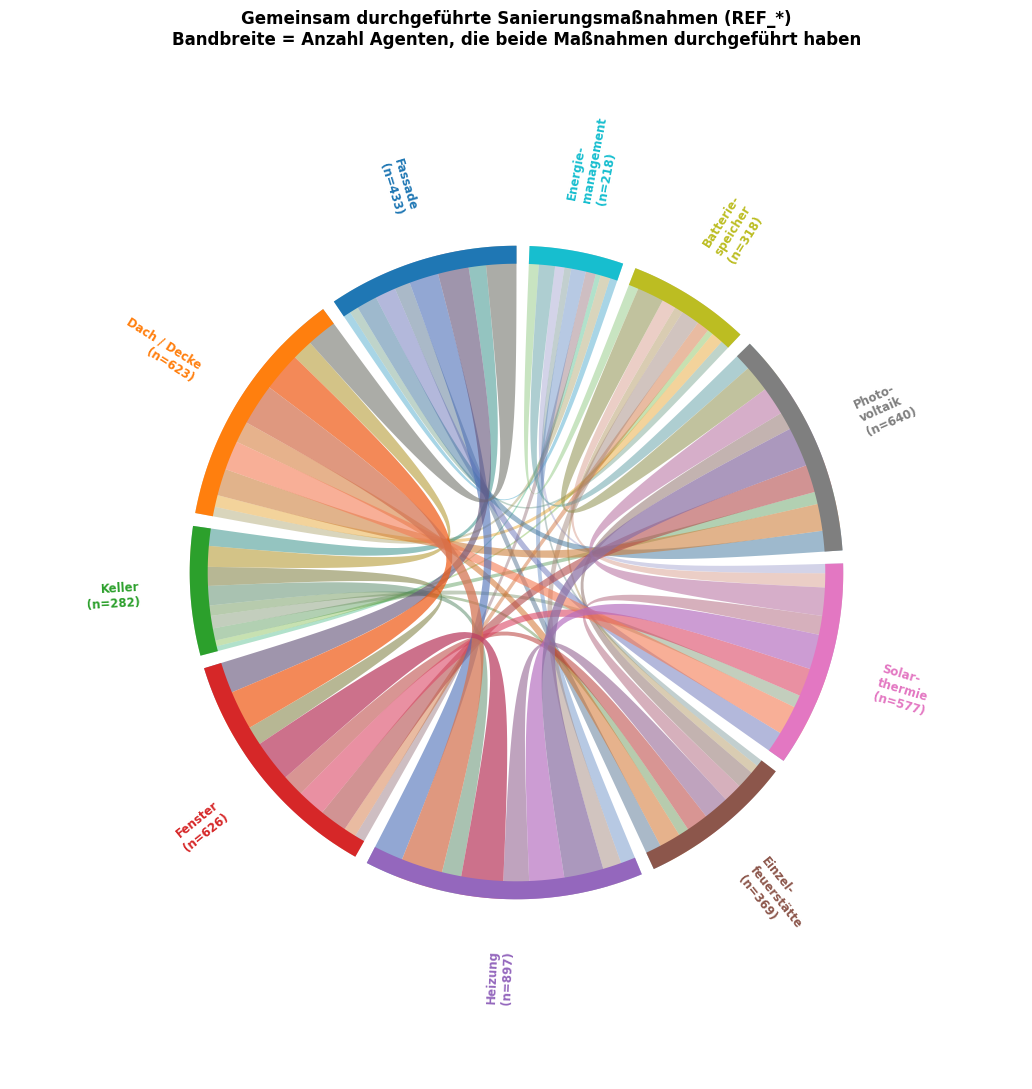

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.path import Path
from matplotlib.colors import to_rgba

# ── Load & filter ─────────────────────────────────────────────────────────────
with open("../data/processed/survey_v1.1.json") as f:
    data = json.load(f)

REF_FIELDS = [f"REF_{i}" for i in range(1, 11)]   # skip REF_11 (Other)
agents = [r for r in data if any(str(r.get(f, "0")) == "1" for f in REF_FIELDS)]
N_NODES = len(REF_FIELDS)
print(f"Agents with at least one REF measure: {len(agents)}")

# ── German labels ─────────────────────────────────────────────────────────────
labels = [
    "Fassade",
    "Dach / Decke",
    "Keller",
    "Fenster",
    "Heizung",
    "Einzel-\nfeuerstätte",
    "Solar-\nthermie",
    "Photo-\nvoltaik",
    "Batterie-\nspeicher",
    "Energie-\nmanagement",
]

# ── Co-occurrence matrix ──────────────────────────────────────────────────────
cooc = np.zeros((N_NODES, N_NODES), dtype=int)
for r in agents:
    active = [i for i, f in enumerate(REF_FIELDS) if str(r.get(f, "0")) == "1"]
    for i in active:
        for j in active:
            if i != j:
                cooc[i][j] += 1

node_weights = cooc.sum(axis=1)   # total connection weight per node
total_weight = node_weights.sum()

# ── Colours (tab10) ───────────────────────────────────────────────────────────
cmap   = plt.cm.tab10
colors = [cmap(i) for i in range(N_NODES)]

# ── Arc layout ────────────────────────────────────────────────────────────────
GAP       = 0.04   # radians between nodes
total_arc = 2 * np.pi - N_NODES * GAP
arc_scale = total_arc / total_weight

# Node arc ranges (start, end) in radians, going counter-clockwise from top
node_start = np.zeros(N_NODES)
node_end   = np.zeros(N_NODES)
angle = np.pi / 2   # start from 12 o'clock
for i in range(N_NODES):
    node_start[i] = angle
    node_end[i]   = angle + node_weights[i] * arc_scale
    angle          = node_end[i] + GAP

# Sub-arc ranges: for node i, the slice going to node j
# Order sub-arcs by target node position to reduce crossing
sub_arc = [[None] * N_NODES for _ in range(N_NODES)]
for i in range(N_NODES):
    j_order = sorted(
        [j for j in range(N_NODES) if j != i and cooc[i][j] > 0],
        key=lambda j: node_start[j]
    )
    offset = node_start[i]
    for j in j_order:
        w = cooc[i][j] * arc_scale
        sub_arc[i][j] = (offset, offset + w)
        offset += w

# ── Drawing helpers ───────────────────────────────────────────────────────────
R = 1.0   # circle radius

def arc_points(t_start, t_end, r=R, n=40):
    t = np.linspace(t_start, t_end, n)
    return r * np.column_stack([np.cos(t), np.sin(t)])

def bezier_to_center(p0, p1, n=50):
    """Cubic bezier from p0 to p1 with both control points at origin."""
    t    = np.linspace(0, 1, n)
    ctrl = np.zeros(2)
    pts  = (np.outer((1-t)**3, p0)
          + np.outer(3*(1-t)**2*t, ctrl)
          + np.outer(3*(1-t)*t**2, ctrl)
          + np.outer(t**3, p1))
    return pts

def draw_chord(ax, i, j):
    if sub_arc[i][j] is None or sub_arc[j][i] is None:
        return
    t1s, t1e = sub_arc[i][j]
    t2s, t2e = sub_arc[j][i]

    arc1 = arc_points(t1s, t1e)
    arc2 = arc_points(t2s, t2e)
    b1   = bezier_to_center(arc1[-1], arc2[0])[1:]
    b2   = bezier_to_center(arc2[-1], arc1[0])[1:]
    poly = np.vstack([arc1, b1, arc2, b2])

    # Blend colours of the two nodes
    c = np.array(to_rgba(colors[i])) * 0.6 + np.array(to_rgba(colors[j])) * 0.4
    alpha = 0.30 + 0.45 * (cooc[i][j] / cooc.max())
    ax.fill(poly[:, 0], poly[:, 1], color=c, alpha=alpha, lw=0, zorder=1)

# ── Figure ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 11))
ax.set_aspect("equal")
ax.axis("off")
ax.set_xlim(-1.55, 1.55)
ax.set_ylim(-1.55, 1.55)

# --- Draw chords (largest last so they appear on top) ---
pairs = sorted(
    [(i, j) for i in range(N_NODES) for j in range(i+1, N_NODES) if cooc[i][j] > 0],
    key=lambda p: cooc[p[0]][p[1]]
)
for i, j in pairs:
    draw_chord(ax, i, j)

# --- Draw node arcs ---
ARC_W = 0.055   # arc thickness
for i in range(N_NODES):
    pts_outer = arc_points(node_start[i], node_end[i], r=R)
    pts_inner = arc_points(node_end[i], node_start[i], r=R - ARC_W)
    ring = np.vstack([pts_outer, pts_inner])
    ax.fill(ring[:, 0], ring[:, 1], color=colors[i], zorder=2, lw=0)

# --- Labels ---
LABEL_R = R + ARC_W + 0.10
for i in range(N_NODES):
    mid_angle = (node_start[i] + node_end[i]) / 2
    x = LABEL_R * np.cos(mid_angle)
    y = LABEL_R * np.sin(mid_angle)

    # Rotate text to follow the circle
    deg = np.degrees(mid_angle)
    if 90 < deg % 360 <= 270:      # left half — flip so text isn't upside down
        deg += 180
    ha = "left" if np.cos(mid_angle) >= 0 else "right"

    freq = sum(1 for r in agents if str(r.get(REF_FIELDS[i], "0")) == "1")
    ax.text(x, y, f"{labels[i]}\n(n={freq})",
            ha=ha, va="center", fontsize=8.5,
            rotation=deg, rotation_mode="anchor",
            color=colors[i], fontweight="bold")

# --- Title ---
ax.set_title(
    "Gemeinsam durchgeführte Sanierungsmaßnahmen (REF_*)\n"
    "Bandbreite = Anzahl Agenten, die beide Maßnahmen durchgeführt haben",
    fontsize=12, fontweight="bold", pad=16
)

plt.tight_layout()
plt.show()